# Projet de Modélisation et Machine Learning - Diagramme HR

## 1) Détermination du type de problème

### 1.1 - Nature du problème

Nous avons un ensemble de données sans labels prédéfinis : nous ne savons pas à l’avance quelles étoiles appartiennent à quel groupe.

Type de problème : Clustering (apprentissage non supervisé)

Objectif : Identifier des regroupements d’étoiles dans le diagramme HR .

### 1.2 - Sélection des modèles 

- **K-Means** : \
Les clusters doivent avoir les mêmes formes et tailles (ce qui pourrait poser problème). \
Nécessite de choisir à l'avance le nombre de clusters.

- **DBSCAN** (Density-based Spatial Clustering of Applications with Noise) : \
Les clusters peuvent être de formes et tailles différentes 

- **Gaussian mixture models** (GMM) : \
Les clusters peuvent être de formes et tailles différentes


### 1.3 - Choix de la métrique pour évaluer les modèles

Comme il s'agit d'un apprentissage non supervisé il sera difficile d'évaluer le modèle. ????
Essayer de labelliser les donnés pour effectuer une comparaison.

## 2) Pré-traitement des données 

In [1]:
### Importation des modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn import decomposition
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture


### 2.1 - Chargement des données

In [2]:
data_true = pd.read_csv("data.csv")

print("Colonnes du dataset :\n", data_true.columns)
print("..............................................................")
print("On affiche quelques lignes du dataset :\n", data_true.head())
print("..............................................................")
print("Dimension des données :\n", data_true.shape)

Colonnes du dataset :
 Index(['Catalog', 'HIP', 'Proxy', 'RAhms', 'DEdms', 'Vmag', 'VarFlag',
       'r_Vmag', 'RAdeg', 'DEdeg', 'AstroRef', 'Plx', 'pmRA', 'pmDE',
       'e_RAdeg', 'e_DEdeg', 'e_Plx', 'e_pmRA', 'e_pmDE', 'DE:RA', 'Plx:RA',
       'Plx:DE', 'pmRA:RA', 'pmRA:DE', 'pmRA:Plx', 'pmDE:RA', 'pmDE:DE',
       'pmDE:Plx', 'pmDE:pmRA', 'F1', 'F2', '---', 'BTmag', 'e_BTmag', 'VTmag',
       'e_VTmag', 'm_BTmag', 'B-V', 'e_B-V', 'r_B-V', 'V-I', 'e_V-I', 'r_V-I',
       'CombMag', 'Hpmag', 'e_Hpmag', 'Hpscat', 'o_Hpmag', 'm_Hpmag', 'Hpmax',
       'HPmin', 'Period', 'HvarType', 'moreVar', 'morePhoto', 'CCDM', 'n_CCDM',
       'Nsys', 'Ncomp', 'MultFlag', 'Source', 'Qual', 'm_HIP', 'theta', 'rho',
       'e_rho', 'dHp', 'e_dHp', 'Survey', 'Chart', 'Notes', 'HD', 'BD', 'CoD',
       'CPD', '(V-I)red', 'SpType', 'r_SpType'],
      dtype='object')
..............................................................
On affiche quelques lignes du dataset :
   Catalog  HIP Proxy        RAhms  

Le dataset est constitué de données sur 118 218 étoiles et de 78 colonnes. Plusieurs de ces colonnes ne nous seront pas utiles.

### 2.2 - Calcul des grandeurs physiques

In [3]:
## On calcule les 3 grandeurs dans data_pca_calcul afin de les utiliser pour la pca

# Copie pour éviter de modifier directement le dataset initial
data_pca_calcul = data_true.copy()

# Filtrer les étoiles avec une parallaxe positive 
data_pca_calcul = data_pca_calcul[data_pca_calcul['Plx'] > 0]

# Calcul de la distance (en pc) 
data_pca_calcul['Distance'] = 1/data_pca_calcul['Plx'] * 1000  

# Calcul de la magnitude absolue 
data_pca_calcul['AbsoluteMag'] = data_pca_calcul['Vmag'] - 5 * np.log10(data_pca_calcul['Distance'] / 10)   

# Fonction pour calculer la température effective des étoiles
def bv_to_temp(bv):
    return 4600 * ((1 / (0.92 * bv + 1.7)) + (1 / (0.92 * bv + 0.62)))

# Ajouter la température aux données
data_pca_calcul['Temperature'] = bv_to_temp(data_pca_calcul['B-V'])

# Vérifier que les colonnes calculées sont bien dans data_pca_calcul
print("Distance est une colonne dans data_pca_calcul:", "Distance" in data_pca_calcul)
print("AbsoluteMag est une colonne dans data_pca_calcul:", "AbsoluteMag" in data_pca_calcul)
print("Temperature est une colonne dans data_pca_calcul:", "Temperature" in data_pca_calcul)

data_pca_calcul

Distance est une colonne dans data_pca_calcul: True
AbsoluteMag est une colonne dans data_pca_calcul: True
Temperature est une colonne dans data_pca_calcul: True


,Catalog,HIP,Proxy,RAhms,DEdms,Vmag,VarFlag,r_Vmag,RAdeg,DEdeg,...,HD,BD,CoD,CPD,(V-I)red,SpType,r_SpType,Distance,AbsoluteMag,Temperature
0,H,1,NaN,00 00 00.22,+01 05 20.4,9.10,NaN,H,0.000912,1.089013,...,224700.0,B+00 5077,NaN,NaN,0.66,F5,S,282.485876,1.845016,6471.667826
1,H,2,NaN,00 00 00.91,-19 29 55.8,9.27,NaN,G,0.003797,-19.498837,...,224690.0,B-20 6688,NaN,NaN,1.04,K3V,4,45.662100,5.972221,4745.140425
2,H,3,NaN,00 00 01.20,+38 51 33.4,6.61,NaN,G,0.005008,38.859286,...,224699.0,B+38 5108,NaN,NaN,0.00,B9,S,355.871886,-1.146468,10368.595588
3,H,4,NaN,00 00 02.01,-51 53 36.8,8.06,NaN,H,0.008382,-51.893546,...,224707.0,NaN,NaN,P-52 12237,0.43,F0V,2,129.032258,2.506509,7044.130880
4,H,5,NaN,00 00 02.39,-40 35 28.4,8.55,NaN,H,0.009965,-40.591224,...,224705.0,NaN,C-41 15372,P-41 9991,0.95,G8III,2,348.432056,0.839409,4991.060700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118213,H,118318,NaN,23 59 51.30,+11 40 25.4,6.99,1.0,H,359.963744,11.673709,...,224673.0,B+10 5018,NaN,NaN,1.56,K2,S,520.833333,-1.593494,3655.993639
118214,H,118319,NaN,23 59 53.74,-22 25 41.4,8.23,NaN,G,359.973913,-22.428180,...,224693.0,NaN,C-23 18108,P-23 8366,0.70,G2V,4,94.073377,3.362666,5818.920292
118215,H,118320,NaN,23 59 54.25,+05 57 23.9,7.59,NaN,H,359.976057,5.956638,...,224689.0,B+05 5245,NaN,NaN,0.98,K0,S,200.000000,1.084850,4745.140425
118216,H,118321,NaN,23 59 54.78,-64 22 21.3,9.20,NaN,G,359.978239,-64.372572,...,224685.0,NaN,C-65 2958,P-65 4188,0.75,G5V,1,52.029136,5.618767,5608.544902


### 2.3 - Traitement des valeurs manquantes

In [4]:
# Afficher les valeurs manquantes 
missing_data = data_pca_calcul.isnull()
nb_missing_value = missing_data.sum()

total_rows = len(data_true)
for col, val in nb_missing_value.items():
    if val > 0:
        percent = (val / total_rows) * 100
        print(f"{col} : {val} NaNs ({percent:.2f}%)")


Proxy : 103157 NaNs (87.26%)
VarFlag : 103202 NaNs (87.30%)
AstroRef : 100675 NaNs (85.16%)
F2 : 1393 NaNs (1.18%)
BTmag : 2696 NaNs (2.28%)
e_BTmag : 2696 NaNs (2.28%)
VTmag : 2640 NaNs (2.23%)
e_VTmag : 2640 NaNs (2.23%)
m_BTmag : 101507 NaNs (85.86%)
B-V : 887 NaNs (0.75%)
e_B-V : 887 NaNs (0.75%)
r_B-V : 887 NaNs (0.75%)
V-I : 887 NaNs (0.75%)
e_V-I : 887 NaNs (0.75%)
CombMag : 103281 NaNs (87.36%)
Hpscat : 786 NaNs (0.66%)
o_Hpmag : 786 NaNs (0.66%)
m_Hpmag : 101141 NaNs (85.55%)
Hpmax : 786 NaNs (0.66%)
HPmin : 786 NaNs (0.66%)
Period : 111507 NaNs (94.32%)
HvarType : 45077 NaNs (38.13%)
moreVar : 106287 NaNs (89.91%)
morePhoto : 110567 NaNs (93.53%)
CCDM : 95330 NaNs (80.64%)
n_CCDM : 95330 NaNs (80.64%)
Nsys : 95330 NaNs (80.64%)
MultFlag : 96731 NaNs (81.82%)
Source : 110786 NaNs (93.71%)
Qual : 94419 NaNs (79.87%)
m_HIP : 102984 NaNs (87.11%)
theta : 102984 NaNs (87.11%)
rho : 102984 NaNs (87.11%)
e_rho : 102984 NaNs (87.11%)
dHp : 102984 NaNs (87.11%)
e_dHp : 102984 NaNs (87

À partir de l'affichage précédent, on selectionne les colonnes inutiles :
- Catalog
- HIP
- Proxy
- VarFlag
- AstroRef
- m_BTmag
- CombMag
- m_Hpmag
- Period
- HvarType
- moreVar
- morePhoto
- CCDM
- n_CCDM
- Nsys
- MultFlag
- Source
- Qual
- m_HIP
- theta
- rho
- e_rho
- dHp
- e_dHp
- Survey
- Chart
- Notes
- HD
- BD
- CoD
- CPD



In [5]:
# On supprime ces colonnes dans data_pca_calcul
colonnes_inutiles = [
    "Catalog", "Proxy", "VarFlag", "AstroRef", "m_BTmag", "CombMag",
    "m_Hpmag", "Period", "HvarType", "moreVar", "morePhoto", "CCDM", "n_CCDM",
    "Nsys", "MultFlag", "Source", "Qual", "m_HIP", "theta", "rho", "e_rho",
    "dHp", "e_dHp", "Survey", "Chart", "Notes", "HD", "BD", "CoD", "CPD"
]
data_pca_modified = data_pca_calcul.drop(columns=colonnes_inutiles)
data_pca_modified

,HIP,RAhms,DEdms,Vmag,r_Vmag,RAdeg,DEdeg,Plx,pmRA,pmDE,...,o_Hpmag,Hpmax,HPmin,Ncomp,(V-I)red,SpType,r_SpType,Distance,AbsoluteMag,Temperature
0,1,00 00 00.22,+01 05 20.4,9.10,H,0.000912,1.089013,3.54,-5.20,-1.88,...,87.0,9.17,9.24,1.0,0.66,F5,S,282.485876,1.845016,6471.667826
1,2,00 00 00.91,-19 29 55.8,9.27,G,0.003797,-19.498837,21.90,181.21,-0.93,...,120.0,9.37,9.44,1.0,1.04,K3V,4,45.662100,5.972221,4745.140425
2,3,00 00 01.20,+38 51 33.4,6.61,G,0.005008,38.859286,2.81,5.24,-2.91,...,127.0,6.60,6.62,1.0,0.00,B9,S,355.871886,-1.146468,10368.595588
3,4,00 00 02.01,-51 53 36.8,8.06,H,0.008382,-51.893546,7.75,62.85,0.16,...,201.0,8.12,8.18,1.0,0.43,F0V,2,129.032258,2.506509,7044.130880
4,5,00 00 02.39,-40 35 28.4,8.55,H,0.009965,-40.591224,2.87,2.53,9.07,...,161.0,8.68,8.74,1.0,0.95,G8III,2,348.432056,0.839409,4991.060700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118213,118318,23 59 51.30,+11 40 25.4,6.99,H,359.963744,11.673709,1.92,-2.16,2.09,...,92.0,7.08,7.12,1.0,1.56,K2,S,520.833333,-1.593494,3655.993639
118214,118319,23 59 53.74,-22 25 41.4,8.23,G,359.973913,-22.428180,10.63,148.74,27.53,...,118.0,8.34,8.39,1.0,0.70,G2V,4,94.073377,3.362666,5818.920292
118215,118320,23 59 54.25,+05 57 23.9,7.59,H,359.976057,5.956638,5.00,20.92,-35.26,...,86.0,7.74,7.77,1.0,0.98,K0,S,200.000000,1.084850,4745.140425
118216,118321,23 59 54.78,-64 22 21.3,9.20,G,359.978239,-64.372572,19.22,216.99,106.46,...,145.0,9.28,9.36,1.0,0.75,G5V,1,52.029136,5.618767,5608.544902


In [6]:
# On affiche les noms des colonnes de data_pca_modified 
data_pca_modified.columns

# Une colonne inconnue "---" est présente dans data_true et donc aussi dans data_pca_modified, il faut l'enlever 
data_pca_modified_2 = data_pca_modified.drop(columns='---')
data_pca_modified_2

,HIP,RAhms,DEdms,Vmag,r_Vmag,RAdeg,DEdeg,Plx,pmRA,pmDE,...,o_Hpmag,Hpmax,HPmin,Ncomp,(V-I)red,SpType,r_SpType,Distance,AbsoluteMag,Temperature
0,1,00 00 00.22,+01 05 20.4,9.10,H,0.000912,1.089013,3.54,-5.20,-1.88,...,87.0,9.17,9.24,1.0,0.66,F5,S,282.485876,1.845016,6471.667826
1,2,00 00 00.91,-19 29 55.8,9.27,G,0.003797,-19.498837,21.90,181.21,-0.93,...,120.0,9.37,9.44,1.0,1.04,K3V,4,45.662100,5.972221,4745.140425
2,3,00 00 01.20,+38 51 33.4,6.61,G,0.005008,38.859286,2.81,5.24,-2.91,...,127.0,6.60,6.62,1.0,0.00,B9,S,355.871886,-1.146468,10368.595588
3,4,00 00 02.01,-51 53 36.8,8.06,H,0.008382,-51.893546,7.75,62.85,0.16,...,201.0,8.12,8.18,1.0,0.43,F0V,2,129.032258,2.506509,7044.130880
4,5,00 00 02.39,-40 35 28.4,8.55,H,0.009965,-40.591224,2.87,2.53,9.07,...,161.0,8.68,8.74,1.0,0.95,G8III,2,348.432056,0.839409,4991.060700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118213,118318,23 59 51.30,+11 40 25.4,6.99,H,359.963744,11.673709,1.92,-2.16,2.09,...,92.0,7.08,7.12,1.0,1.56,K2,S,520.833333,-1.593494,3655.993639
118214,118319,23 59 53.74,-22 25 41.4,8.23,G,359.973913,-22.428180,10.63,148.74,27.53,...,118.0,8.34,8.39,1.0,0.70,G2V,4,94.073377,3.362666,5818.920292
118215,118320,23 59 54.25,+05 57 23.9,7.59,H,359.976057,5.956638,5.00,20.92,-35.26,...,86.0,7.74,7.77,1.0,0.98,K0,S,200.000000,1.084850,4745.140425
118216,118321,23 59 54.78,-64 22 21.3,9.20,G,359.978239,-64.372572,19.22,216.99,106.46,...,145.0,9.28,9.36,1.0,0.75,G5V,1,52.029136,5.618767,5608.544902


In [7]:
# Enlever les NaN restants 
data_pca_modified_3 = data_pca_modified_2.dropna(axis=0)

### 2.4 - Endodage des valeurs catégorielles

In [8]:
## Il faut maintenant encoder les colonnes qui ne sont pas des int64 ou des float64 

# Pour cela, on commence par afficher le type de chaque colonne 
print(data_pca_modified_3.dtypes)

HIP              int64
RAhms           object
DEdms           object
Vmag           float64
r_Vmag          object
RAdeg          float64
DEdeg          float64
Plx            float64
pmRA           float64
pmDE           float64
e_RAdeg        float64
e_DEdeg        float64
e_Plx          float64
e_pmRA         float64
e_pmDE         float64
DE:RA          float64
Plx:RA         float64
Plx:DE         float64
pmRA:RA        float64
pmRA:DE        float64
pmRA:Plx       float64
pmDE:RA        float64
pmDE:DE        float64
pmDE:Plx       float64
pmDE:pmRA      float64
F1             float64
F2             float64
BTmag          float64
e_BTmag        float64
VTmag          float64
e_VTmag        float64
B-V            float64
e_B-V          float64
r_B-V           object
V-I            float64
e_V-I          float64
r_V-I           object
Hpmag          float64
e_Hpmag        float64
Hpscat         float64
o_Hpmag        float64
Hpmax          float64
HPmin          float64
Ncomp      

In [9]:
# Pour encoder ces colonnes, il faut ajouter leur nom dans une liste 
cols_encoder = []
for col, dtype in data_pca_modified_3.dtypes.items():
    if dtype not in ["float64", "int64"]:
        cols_encoder.append(col)

print("Colonnes à encoder :", cols_encoder)


Colonnes à encoder : ['RAhms', 'DEdms', 'r_Vmag', 'r_B-V', 'r_V-I', 'SpType', 'r_SpType']


In [10]:
# Encodage 
label_encoders = {}

for col in cols_encoder:

    if col in data_pca_modified_3.columns:
        le = LabelEncoder()

        if data_pca_modified_3[col].dtype == 'object':
            data_pca_modified_3.loc[:, col] = le.fit_transform(data_pca_modified_3[col])
            label_encoders[col] = le


data_pca_modified_3

,HIP,RAhms,DEdms,Vmag,r_Vmag,RAdeg,DEdeg,Plx,pmRA,pmDE,...,o_Hpmag,Hpmax,HPmin,Ncomp,(V-I)red,SpType,r_SpType,Distance,AbsoluteMag,Temperature
0,1,0,865,9.10,1,0.000912,1.089013,3.54,-5.20,-1.88,...,87.0,9.17,9.24,1.0,0.66,1763,6,282.485876,1.845016,6471.667826
1,2,1,66207,9.27,0,0.003797,-19.498837,21.90,181.21,-0.93,...,120.0,9.37,9.44,1.0,1.04,3092,3,45.662100,5.972221,4745.140425
2,3,2,30564,6.61,0,0.005008,38.859286,2.81,5.24,-2.91,...,127.0,6.60,6.62,1.0,0.00,1327,6,355.871886,-1.146468,10368.595588
3,4,3,92364,8.06,1,0.008382,-51.893546,7.75,62.85,0.16,...,201.0,8.12,8.18,1.0,0.43,1566,1,129.032258,2.506509,7044.130880
4,5,4,83015,8.55,1,0.009965,-40.591224,2.87,2.53,9.07,...,161.0,8.68,8.74,1.0,0.95,2580,1,348.432056,0.839409,4991.060700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118213,118318,107093,9188,6.99,1,359.963744,11.673709,1.92,-2.16,2.09,...,92.0,7.08,7.12,1.0,1.56,2932,6,520.833333,-1.593494,3655.993639
118214,118319,107094,68346,8.23,0,359.973913,-22.428180,10.63,148.74,27.53,...,118.0,8.34,8.39,1.0,0.70,2235,3,94.073377,3.362666,5818.920292
118215,118320,107095,4722,7.59,1,359.976057,5.956638,5.00,20.92,-35.26,...,86.0,7.74,7.77,1.0,0.98,2691,6,200.000000,1.084850,4745.140425
118216,118321,107096,100564,9.20,0,359.978239,-64.372572,19.22,216.99,106.46,...,145.0,9.28,9.36,1.0,0.75,2407,0,52.029136,5.618767,5608.544902


### 2.5 - Séparation en train/validation/test

Taille du train : (75443, 50)
Taille du validation : (16167, 50)
Taille du test : (16167, 50)


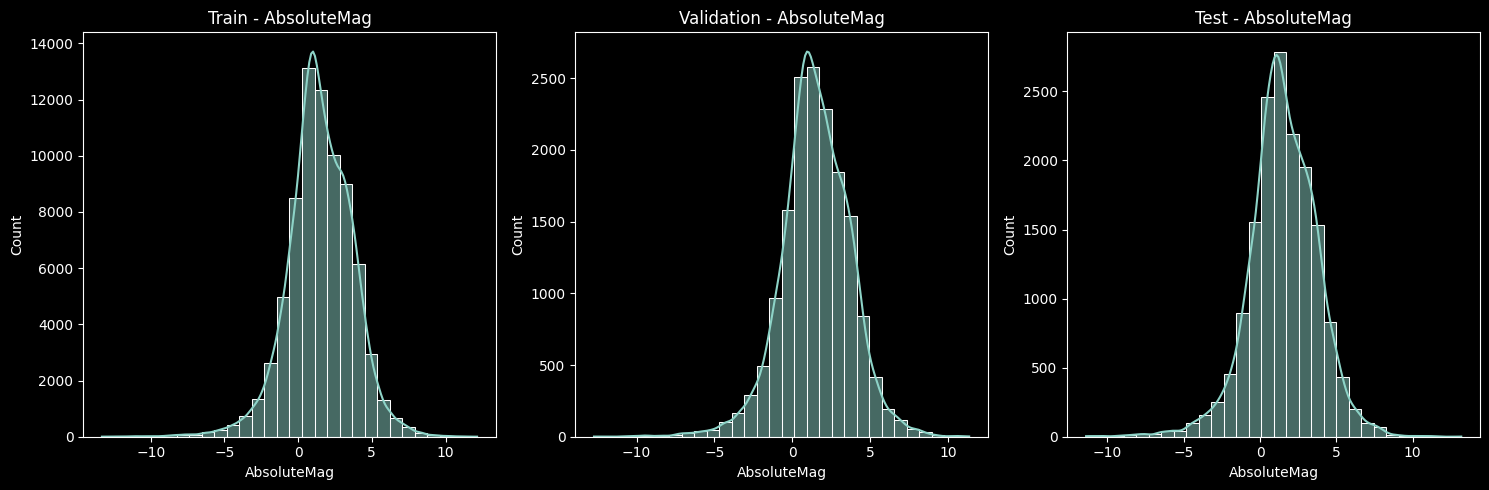

In [11]:
# Séparation en train/validation/test
X_train, X_temp = train_test_split(data_pca_modified_3, test_size=0.3, random_state=0)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=0)

print(f"Taille du train : {X_train.shape}")
print(f"Taille du validation : {X_val.shape}")
print(f"Taille du test : {X_test.shape}")

# Visualiser les données de chaque ensemble (par exemple avec AbsoluteMag)
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(X_train['AbsoluteMag'], bins=30, kde=True, ax=axes[0]).set_title("Train - AbsoluteMag")
sns.histplot(X_val['AbsoluteMag'], bins=30, kde=True, ax=axes[1]).set_title("Validation - AbsoluteMag")
sns.histplot(X_test['AbsoluteMag'], bins=30, kde=True, ax=axes[2]).set_title("Test - AbsoluteMag")
plt.tight_layout()
plt.show()

### 2.6 - Normalisation des données

Plusieurs méthodes existent pour normaliser les données.

In [12]:
# Normaliser les ensembles de donnnées 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = X_train.columns)

X_val_scaled = scaler.fit_transform(X_val)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns = X_val.columns)

X_test_scaled = scaler.fit_transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns = X_test.columns)



In [13]:
## Scaler MinMax
#scaler = MinMaxScaler()
#X_scaled = scaler.fit_transform(X)
#X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)
#X_scaled_df
#Does not reduce the effect of outliers

In [14]:
## Robust scaler 
#scaler = RobustScaler()
#X_scaled = scaler.fit_transform(X)
#X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)
#X_scaled_df

#scaler = PowerTransformer()
#X_scaled = scaler.fit_transform(X)
#X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)
#X_scaled_df

#StandardScaler, 
# MinMaxScaler, mélange des points 
# RobustScaler, score approx 0.9 mais  
# QuantileTransformer, Uniform- no, Normal- forme de cluster se rapproche mais bas score
# Normalizer, mélange des groupes
# MaxAbsScaler, similaire à MinMax
# PowerTransformer, similaire à quantile normal

## 3) PCA

In [15]:
# Appliquer la PCA sur les ensembles de données
pca_1 = decomposition.PCA(n_components=2)   # mettre 2 composantes par défaut pour l'instant 
pca_1.fit(X_train_scaled_df)
print("Avant : \n", X_train_scaled_df.iloc[:10, :])

X_train_t = pca_1.transform(X_train_scaled_df)
print("Dimension de data_t :", X_train_scaled_df.shape)
print("Après :\n", X_train_t[:10,:])

X_train_t_df = pd.DataFrame(X_train_t, columns=['Col1', 'Col2'])



pca_2 = decomposition.PCA(n_components=2)   
pca_2.fit(X_val_scaled_df)
print("Avant : \n", X_val_scaled_df.iloc[:10, :])

X_val_t = pca_2.transform(X_val_scaled_df)
print("Dimension de data_t :", X_val_scaled_df.shape)
print("Après :\n", X_val_t[:10,:])

X_val_t_df = pd.DataFrame(X_val_t, columns=['Col1', 'Col2'])



pca_3 = decomposition.PCA(n_components=2)   
pca_3.fit(X_test_scaled_df)
print("Avant : \n", X_test_scaled_df.iloc[:10, :])

X_test_t = pca_3.transform(X_test_scaled_df)
print("Dimension de data_t :", X_test_scaled_df.shape)
print("Après :\n", X_test_t[:10,:])

X_test_t_df = pd.DataFrame(X_test_t, columns=['Col1', 'Col2'])

Avant : 
         HIP     RAhms     DEdms      Vmag    r_Vmag     RAdeg     DEdeg  \
0 -1.170779 -1.172520 -0.243201 -1.224864 -2.089871 -1.160856  1.561227   
1 -0.535335 -0.537033 -0.024835 -1.710389 -2.089871 -0.545963  0.028064   
2  1.207917  1.206565 -1.046247 -0.144987  0.458886  1.201158  0.691039   
3 -0.529834 -0.531408 -0.883697  0.784209  0.458886 -0.540232  0.849445   
4 -1.298957 -1.300180 -1.720656 -0.781193 -2.089871 -1.295254  0.055357   
5 -0.641247 -0.642257  0.504418  1.646436  0.458886 -0.645980 -0.508196   
6  0.842900  0.841721 -1.339123 -0.823049  0.458886  0.852587  0.418547   
7  1.319271  1.319128 -0.267118  0.675385  0.458886  1.310281  1.523232   
8 -0.381352 -0.381022 -1.406979  0.784209  0.458886 -0.390791  0.354817   
9  0.840325  0.839231 -0.563044 -1.233235 -2.089871  0.850090  1.165931   

        Plx      pmRA      pmDE  ...   o_Hpmag     Hpmax     HPmin     Ncomp  \
0 -0.652050  0.012937  0.209991  ...  0.009753 -1.233207 -1.244245 -0.322782   
1  2

## 6) Labellisation des données

Étant donné que les données d'étoiles ne sont pas préalablement labellisées, nous allons attribuer des catégories aux étoiles en nous basant sur notre connaissance de la physique des diagrammes HR. Sur ce diagramme, chaque catégorie d'étoile se situe dans une zone spécifique en fonction de son indice de couleur (B-V) et de sa magnitude absolue (AbsoluteMag). Nous allons ainsi tracer les courbes correspondant à chacune des catégories d'étoiles (Séquence principale, Géantes, Supergéantes, Naines blanches), et, en posant des conditions sur les indices de couleur, nous pourrons associer à chaque étoile un type basé sur sa position dans le diagramme.

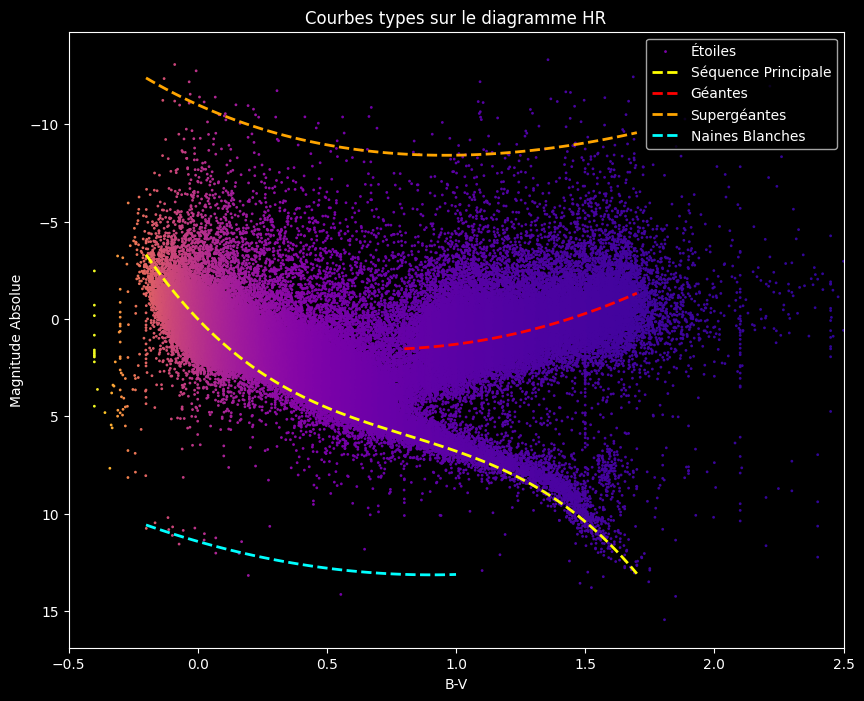

In [16]:
def mag_seq_princ(bv):
    return 4.95 * bv**3 - 12.07 * bv**2 + 13.91 * bv

def mag_geantes(bv):
    return -2.1 * bv**2.2 + 2.9 * bv + 0.5

def mag_supergiantes(bv):
    return -6 * np.exp(-bv) - 1.2 * bv**2 - 5

def mag_naines_blanches(bv):
    return -2.1 * (bv + 0.5)**2 + 5.9 * (bv + 0.5) + 9

bv_seq_princ = np.linspace(-0.2, 1.7, 100)
bv_geantes = np.linspace(0.8, 1.7, 100) 
bv_superg = np.linspace(-0.2, 1.7, 100) 
bv_naine_blanche = np.linspace(-0.2, 1.0, 100)

abs_mag_seq_princ = mag_seq_princ(bv_seq_princ)
abs_mag_geantes = mag_geantes(bv_geantes)
abs_mag_superg = mag_supergiantes(bv_superg)
abs_mag_naine_blanche = mag_naines_blanches(bv_naine_blanche)

# Tracer les courbes
plt.figure(figsize=(10, 8))
plt.scatter(data_pca_calcul['B-V'], data_pca_calcul['AbsoluteMag'], s=1, c=data_pca_calcul['Temperature'], cmap="plasma", label='Étoiles')
plt.plot(bv_seq_princ, abs_mag_seq_princ, color='yellow', linestyle='--', linewidth=2, label='Séquence Principale')
plt.plot(bv_geantes, abs_mag_geantes, color='red', linestyle='--', linewidth=2, label='Géantes')
plt.plot(bv_superg, abs_mag_superg, color='orange', linestyle='--', linewidth=2, label='Supergéantes')
plt.plot(bv_naine_blanche, abs_mag_naine_blanche, color='cyan', linestyle='--', linewidth=2, label='Naines Blanches')
plt.gca().invert_yaxis()
plt.xlim(-0.5, 2.5)
plt.xlabel("B-V")
plt.ylabel("Magnitude Absolue")
plt.title("Courbes types sur le diagramme HR")
plt.legend()
plt.show()


Nous définissons une fonction **labelliser_etoile** qui, pour chaque étoile, utilise ses valeurs de B-V et de magnitude absolue pour déterminer à quel type d'étoile elle appartient. Cette fonction évalue la distance de chaque étoile par rapport aux courbes théoriques pour les différentes catégories d'étoiles. En fonction de la distance la plus faible, l'étoile se voit attribuer le type correspondant.

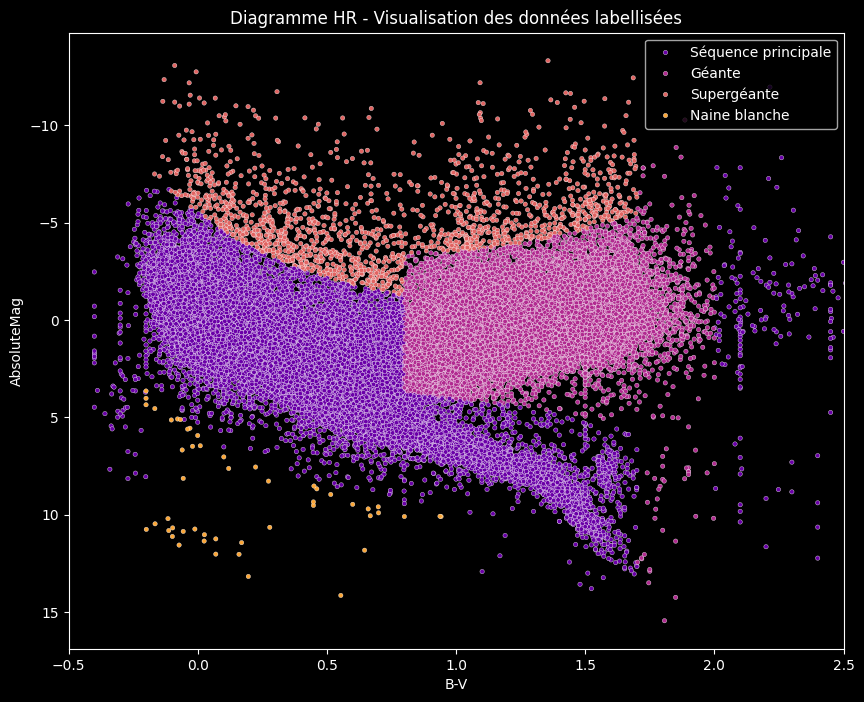

In [17]:
def labelliser_etoile(row):
    bv = row['B-V']
    mag = row['AbsoluteMag']
    
    if np.isnan(bv) or np.isnan(mag):
        return np.nan

    distances = {}

    if -0.2 <= bv <= 1.7:
        distances['Séquence principale'] = abs(mag - mag_seq_princ(bv))
    else:
        distances['Séquence principale'] = np.inf

    if 0.8 <= bv <= 2.0:
        distances['Géante'] = abs(mag - mag_geantes(bv))
    else:
        distances['Géante'] = np.inf

    if -0.2 <= bv <= 1.7:
        distances['Supergéante'] = abs(mag - mag_supergiantes(bv))
    else:
        distances['Supergéante'] = np.inf

    if -0.2 <= bv <= 1.0:
        distances['Naine blanche'] = abs(mag - mag_naines_blanches(bv))
    else:
        distances['Naine blanche'] = np.inf

    return min(distances, key=distances.get)



data_pca_calcul.loc[:, 'Type_Étoile'] = data_pca_calcul.apply(labelliser_etoile, axis=1)



plt.figure(figsize=(10, 8))
sns.scatterplot(data=data_pca_calcul, x='B-V', y='AbsoluteMag', hue='Type_Étoile', palette='plasma', s=10)
plt.gca().invert_yaxis()
plt.xlim(-0.5, 2.5)
plt.title("Diagramme HR - Visualisation des données labellisées")
plt.legend()
plt.show()


## 5) K_Means (sans PCA)

### 5.1 - Entrainement 

In [18]:
# On vérifie qu'il n'y pas de valeurs manquantes dans les données
print(X_train.isnull().sum()) 

HIP            0
RAhms          0
DEdms          0
Vmag           0
r_Vmag         0
RAdeg          0
DEdeg          0
Plx            0
pmRA           0
pmDE           0
e_RAdeg        0
e_DEdeg        0
e_Plx          0
e_pmRA         0
e_pmDE         0
DE:RA          0
Plx:RA         0
Plx:DE         0
pmRA:RA        0
pmRA:DE        0
pmRA:Plx       0
pmDE:RA        0
pmDE:DE        0
pmDE:Plx       0
pmDE:pmRA      0
F1             0
F2             0
BTmag          0
e_BTmag        0
VTmag          0
e_VTmag        0
B-V            0
e_B-V          0
r_B-V          0
V-I            0
e_V-I          0
r_V-I          0
Hpmag          0
e_Hpmag        0
Hpscat         0
o_Hpmag        0
Hpmax          0
HPmin          0
Ncomp          0
(V-I)red       0
SpType         0
r_SpType       0
Distance       0
AbsoluteMag    0
Temperature    0
dtype: int64


In [19]:
# Entraînement du modèle k=4
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
kmeans.fit(X_train_scaled_df)

KMeans(n_clusters=4, n_init=10, random_state=0)

In [20]:
print("Centres des clusters :")
print(kmeans.cluster_centers_) 
X_train

Centres des clusters :
[[-2.00654083e-02 -2.00801082e-02  3.62014679e-02  3.40843997e-01
  -1.17412040e-01 -2.00765140e-02 -2.94443323e-03  6.19377747e-02
  -8.26494084e-03  3.43151248e-03 -7.04905848e-02 -5.08722016e-02
  -3.87592274e-02 -7.48093866e-02 -4.76724901e-02 -1.61200326e-02
   1.63528753e-02  4.52216120e-02  3.49517590e-02  5.72631125e-04
  -5.11624556e-03  4.69237152e-03  3.89466430e-02 -1.31841510e-02
  -6.43185358e-03 -6.88504352e-02 -3.85323133e-02  4.33950732e-03
  -2.48966855e-01  3.10694412e-01 -3.18493177e-02 -6.10583396e-01
  -1.06723888e-01 -6.58293119e-02 -5.45238407e-01 -1.65334648e-01
  -4.02414449e-02  3.24544307e-01 -6.38678328e-02 -5.00272585e-02
   7.42823550e-02  3.29391079e-01  3.19528557e-01 -4.55927460e-02
  -5.30418555e-01 -5.43889398e-01 -8.93479334e-02 -4.85517196e-02
   3.54392327e-01  4.60554360e-01]
 [-2.86342126e-03 -2.88067418e-03  4.05432568e-02 -1.20377081e-01
   3.48439874e-01 -3.24474089e-03 -3.08963885e-02 -4.28061201e-01
   6.20788665e-03 

,HIP,RAhms,DEdms,Vmag,r_Vmag,RAdeg,DEdeg,Plx,pmRA,pmDE,...,o_Hpmag,Hpmax,HPmin,Ncomp,(V-I)red,SpType,r_SpType,Distance,AbsoluteMag,Temperature
19121,19139,17253,45694,6.76,0,61.533603,62.101836,1.45,-0.52,-0.46,...,111.0,6.82,6.85,1.0,0.40,700,7,689.655172,-2.433160,7901.660788
40825,40858,36911,52423,6.18,0,125.054069,-0.909103,24.50,39.29,-86.53,...,67.0,6.30,6.31,1.0,0.68,2053,7,40.816327,3.125830,5940.269764
100350,100441,90847,20948,8.05,1,305.537674,26.338274,4.26,2.03,-0.33,...,136.0,8.01,8.05,1.0,-0.09,682,7,234.741784,1.197048,11310.572070
41012,41046,37085,25957,9.16,1,125.646124,32.848557,6.98,6.64,-32.89,...,117.0,9.23,9.30,1.0,0.41,1602,6,143.266476,3.379277,6699.187413
14745,14758,13304,166,7.29,0,47.649780,0.212585,7.85,-6.43,-32.96,...,111.0,7.34,7.37,1.0,0.28,263,6,127.388535,1.764348,7795.184395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23321,23339,21108,6183,8.69,0,75.303202,7.869300,5.50,-4.96,-16.99,...,80.0,8.79,8.84,1.0,0.65,1973,6,181.818182,2.391813,6042.947477
50267,50306,45575,63769,7.29,1,154.068085,-16.142113,6.61,-45.98,9.97,...,83.0,7.44,7.48,1.0,0.96,2752,3,151.285930,1.391007,4730.765334
46714,46748,42319,47664,8.15,1,142.925674,66.855439,3.00,-21.83,-32.65,...,205.0,8.19,8.26,1.0,0.28,1516,6,333.333333,0.535606,7506.642848
47742,47778,43267,32877,9.29,1,146.111354,41.745559,1.78,-15.48,0.85,...,133.0,9.42,9.48,1.0,1.20,2932,6,561.797753,0.542100,4141.202460


In [21]:
# Prédire les clusters pour l'ensemble d'entraînement
train_clusters = kmeans.predict(X_train_scaled_df)

# Ajouter les clusters comme une nouvelle colonne dans X_train
X_train['Cluster'] = train_clusters


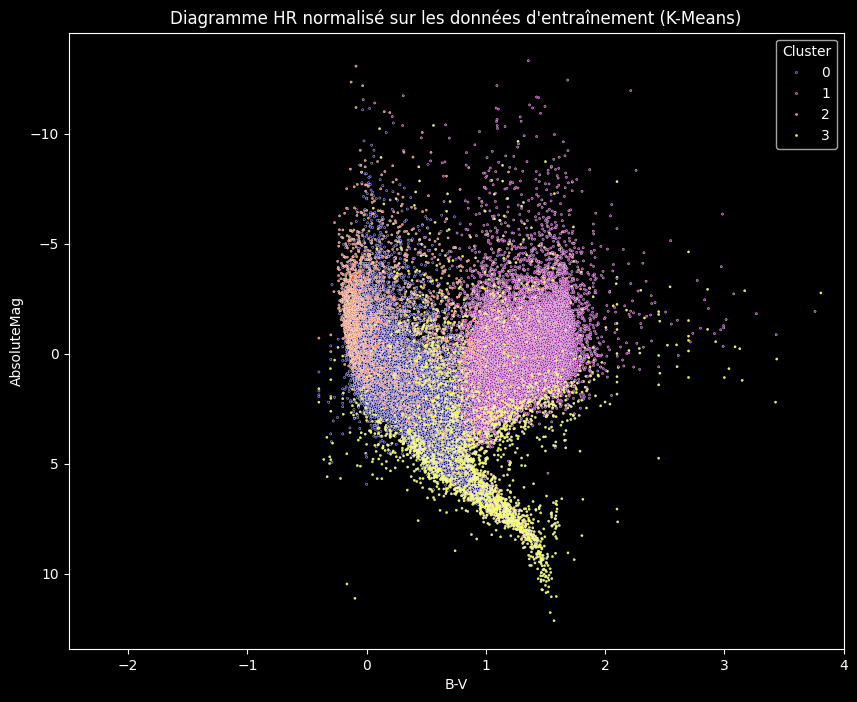

In [22]:
plt.figure(figsize=(10, 8))
plt.style.use('dark_background')
sns.scatterplot(x=X_train['B-V'], y=X_train['AbsoluteMag'], hue=X_train['Cluster'], palette='plasma', marker='.', s=10) 
plt.title("Diagramme HR normalisé sur les données d'entraînement (K-Means)")
plt.gca().invert_yaxis()  # il faut inverser l'axe de AbsoluteMag par convention du diagramme HR
plt.xlim(-2.5, 4)
plt.show()



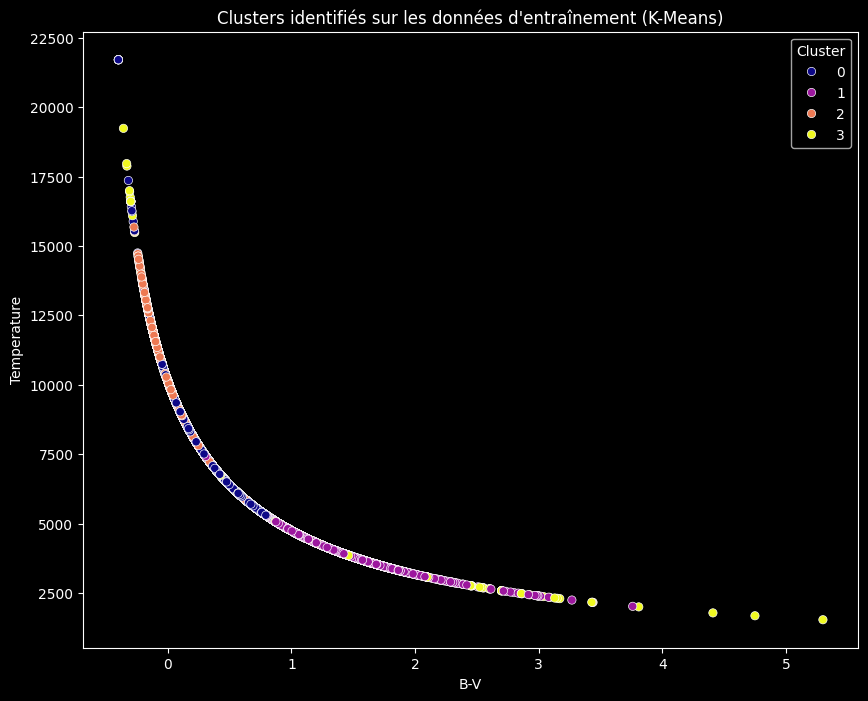

In [23]:
plt.figure(figsize=(10, 8))
plt.style.use('dark_background')
sns.scatterplot(x=X_train['B-V'], y=X_train['Temperature'], hue=X_train['Cluster'], palette='plasma', marker='o') 
plt.title("Clusters identifiés sur les données d'entraînement (K-Means)")
plt.show()

La courbe ci-dessous peut-être intéressante pour visualiser la relation entre la température et l'indice de couleurs B-V.

### 5.2 - Évaluation du modèle

In [24]:
# Evaluer la qualité des clusters : Le silhouette score mesure à quel point chaque point est bien classé dans son cluster comparé aux autres clusters
score = silhouette_score(X_train, kmeans.labels_) 
print("Silhouette Score :", score)

# Si la valeur est proche de 1 alors on a un meilleur clustering


Silhouette Score : -0.018919782893147725


In [25]:
#samples = silhouette_samples(X_train, kmeans.labels_)
#plt.bar(range(len(samples)), samples)
#plt.title("Silhouette Coefficient for each point")
#plt.xlabel("Point index")
#plt.ylabel("Silhouette score")
#plt.show()

## 6) K_Means (avec PCA)

### 6.1 - Entrainement et validation

In [26]:
# Entraînement du modèle k=4
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(X_train_t_df)

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=4, random_state=0)

In [27]:
print("Centres des clusters :")
print(kmeans.cluster_centers_) 

Centres des clusters :
[[-3.86632543  0.94300665]
 [ 4.55101896  0.86619363]
 [ 0.11156132 -2.47184407]
 [ 0.09011953  1.25776488]]


In [28]:
# Prédire les clusters
train_clusters_kmeans = kmeans.predict(X_val_t_df)

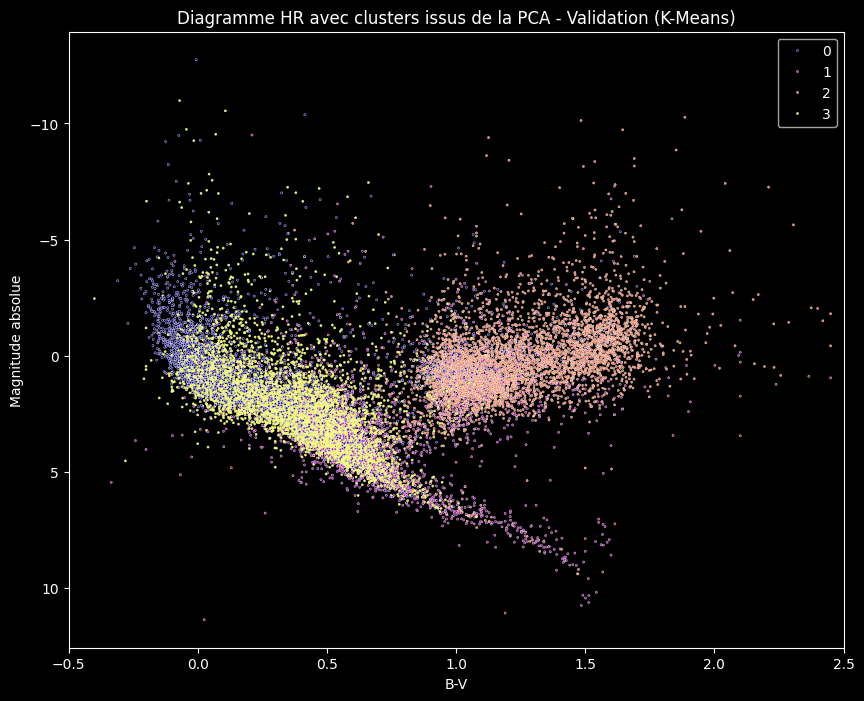

In [29]:
# Faire une copie des données utilisées pour la PCA 
X_val_hr = X_val.copy()
X_val_hr = X_val_hr.reset_index(drop=True)

# Ajouter les labels des clusters
X_val_hr['Cluster'] = train_clusters_kmeans

# Diagramme HR 
plt.figure(figsize=(10, 8))
plt.style.use('dark_background')
sns.scatterplot(x=X_val_hr['B-V'], y=X_val_hr['AbsoluteMag'], hue=train_clusters_kmeans, palette='plasma', marker='.', s=10)   # on n'utilise pas kmeans.labels_ car il est lié au X_train
plt.title("Diagramme HR avec clusters issus de la PCA - Validation (K-Means)")
plt.xlim(-0.5, 2.5)
plt.xlabel('B-V')
plt.ylabel('Magnitude absolue')
plt.gca().invert_yaxis() 
plt.show()

# ce diagramme peut servir à verifier les clusters


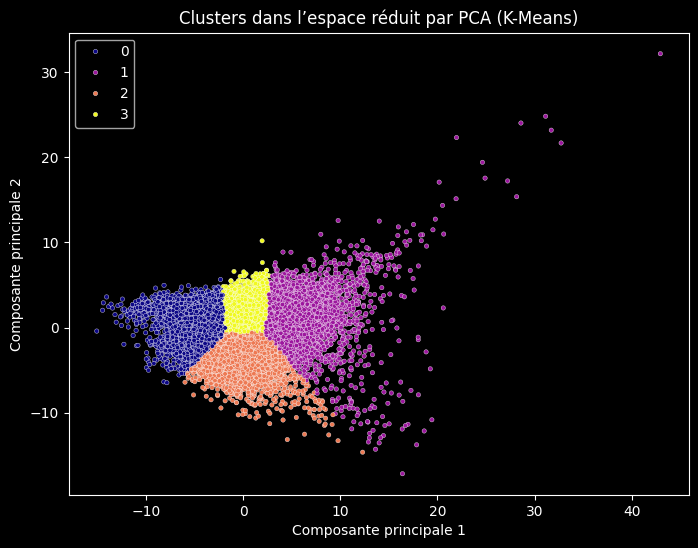

In [30]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_train_t_df['Col1'], y=X_train_t_df['Col2'], hue=kmeans.labels_, palette='plasma', s=10)
plt.title("Clusters dans l’espace réduit par PCA (K-Means)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend()
plt.show()

In [31]:
score = silhouette_score(X_train_t_df, kmeans.labels_)
print("Score silhouette moyen :", score)

### 6.2 - Test

In [ ]:
# Prédire les clusters
train_clusters_kmeans = kmeans.predict(X_test_t_df)

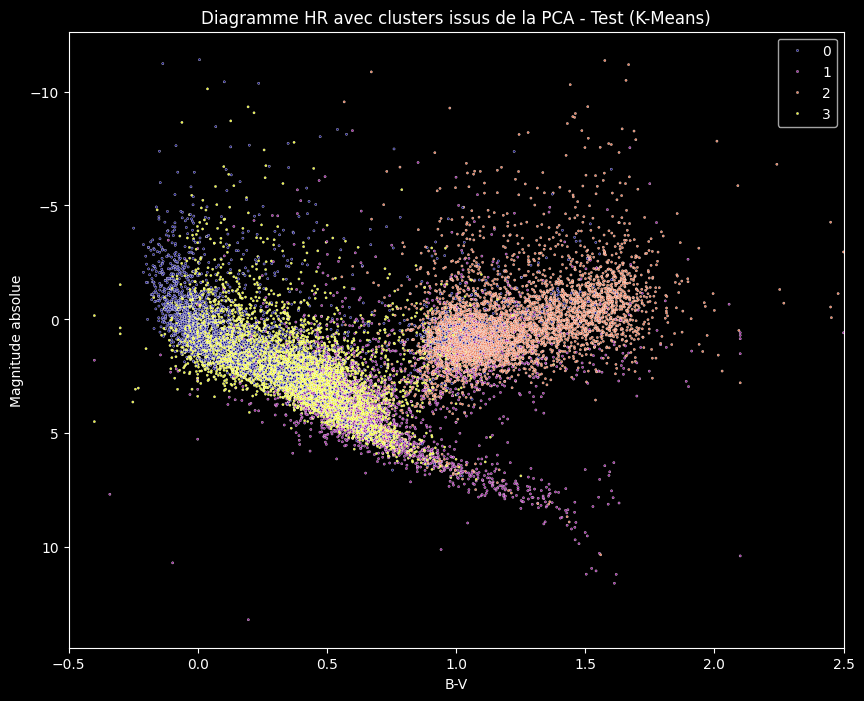

In [ ]:
# Faire une copie de data_pca_modified_3
X_test_hr = X_test.copy()
X_test_hr = X_test_hr.reset_index(drop=True)

# Ajouter les labels des clusters
X_test_hr['Cluster'] = train_clusters_kmeans

# Diagramme HR 
plt.figure(figsize=(10, 8))
plt.style.use('dark_background')
sns.scatterplot(x=X_test_hr['B-V'], y=X_test_hr['AbsoluteMag'], hue=train_clusters_kmeans, palette='plasma', marker='.', s=10)
plt.title("Diagramme HR avec clusters issus de la PCA - Test (K-Means)")
plt.xlim(-0.5, 2.5)
plt.xlabel('B-V')
plt.ylabel('Magnitude absolue')
plt.gca().invert_yaxis() 
plt.show()

# ce diagramme peut servir à verifier les clusters


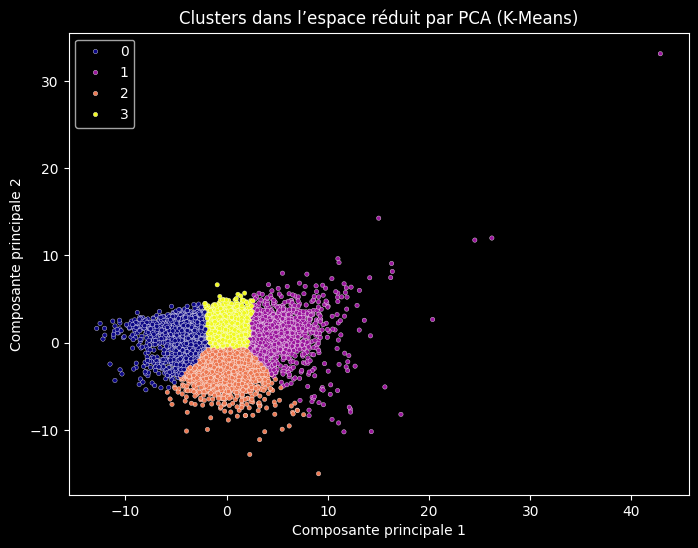

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_test_t_df['Col1'], y=X_test_t_df['Col2'], hue=train_clusters_kmeans, palette='plasma', s=10)
plt.title("Clusters dans l’espace réduit par PCA (K-Means)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend()
plt.show()

In [ ]:
score = silhouette_score(X_test_t_df, X_test_hr['Cluster'])
print("Score silhouette moyen :", score)

Score silhouette moyen : 0.35122171601910607


### 6.3 - Optimisation des nombres de composantes et clusters

Nombre de composantes pour atteindre 95% de variance : 28


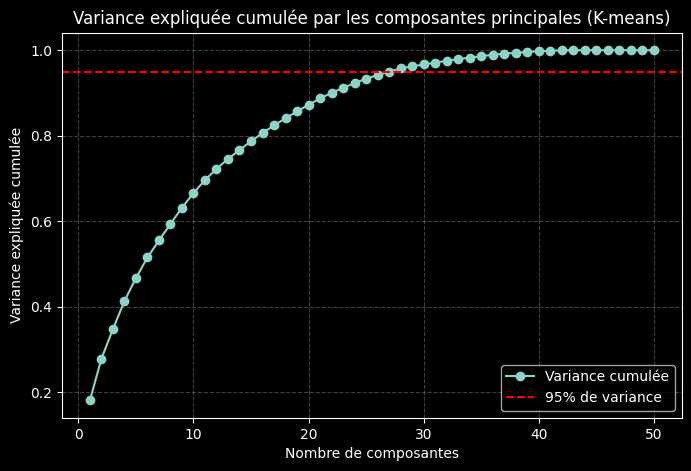

In [ ]:
## Optimisation du nombre de composantes de la PCA sur les données d'entrainement

# Appliquer la PCA sans préciser le nombre de composantes
pca = PCA()
pca.fit(X_train_scaled_df) 

# Récupérer la variance expliquée par chaque composante
explained_variance = pca.explained_variance_ratio_

# Calculer la variance cumulée
variance_cumsum = np.cumsum(explained_variance)

# Trouver le nombre de composantes qui expliquent au moins 95% de la variance
n_components_95 = np.argmax(variance_cumsum >= 0.95) + 1  
print(f"Nombre de composantes pour atteindre 95% de variance : {n_components_95}")


plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), variance_cumsum, marker='o', label='Variance cumulée')
plt.axhline(y=0.95, color='r', linestyle='--', label="95% de variance")
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée')
plt.title('Variance expliquée cumulée par les composantes principales (K-means)')
plt.grid(linestyle='--', color='gray', alpha=0.5)
plt.legend()
plt.show()

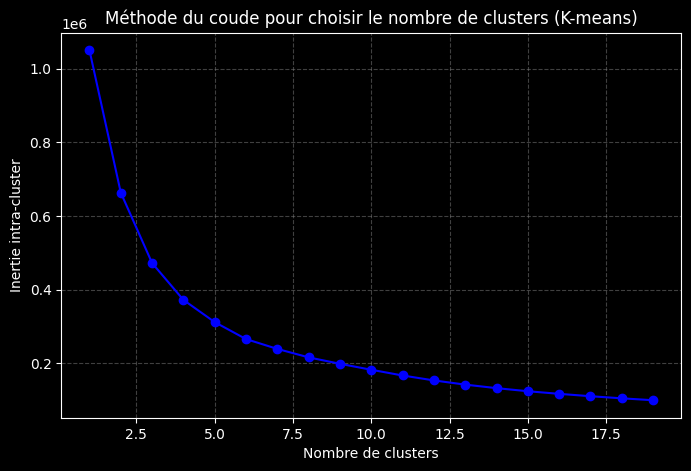

In [ ]:
## Optimisation du nombre de clusters sur les données d'entrainement

inertias = []
cluster_range = range(1, 20)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)  # n_init : nombre d'initialisations (points de départ différents pour chaque initialisation)
    kmeans.fit(X_train_t_df)  
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertias, marker='o', color="blue")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie intra-cluster")
plt.title("Méthode du coude pour choisir le nombre de clusters (K-means)")
plt.grid(linestyle='--', color='gray', alpha=0.5)
plt.show()


On observe qu’au début, l’inertie diminue fortement lorsque le nombre de clusters augmente (jusqu’à environ 4). Ensuite, la diminution devient plus progressive. Ce changement de rythme correspond au "coude". On peut donc choisir le nombre optimal de clusters au niveau de ce coude, là où l’ajout de nouveaux clusters n’apporte plus d’amélioration significative. 

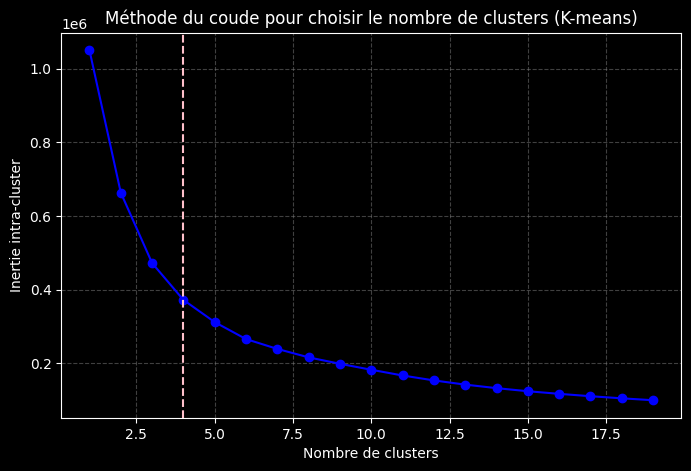

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertias, marker='o', color="blue")
plt.axvline(x=4, linestyle='--', color='pink')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie intra-cluster")
plt.title("Méthode du coude pour choisir le nombre de clusters (K-means)")
plt.grid(linestyle='--', color='gray', alpha=0.5)
plt.show()

On peut généraliser à l'aide d'une fonction afin de modifier facilement les nombres de composantes et clusters.

In [ ]:
def pca_kmeans(nb_comp, nb_cluster):

    # Appliquer la PCA sur les ensembles de données
    pca_1 = decomposition.PCA(n_components=nb_comp)   
    X_train_t = pca_1.fit_transform(X_train_scaled_df)
    X_train_t_df = pd.DataFrame(X_train_t, columns=[f'Col{i+1}' for i in range(nb_comp)])

    pca_2 = decomposition.PCA(n_components=nb_comp)   
    X_val_t = pca_2.fit_transform(X_val_scaled_df)
    X_val_t_df = pd.DataFrame(X_val_t, columns=[f'Col{i+1}' for i in range(nb_comp)])

    pca_3 = decomposition.PCA(n_components=nb_comp) 
    X_test_t = pca_3.fit_transform(X_test_scaled_df)  
    X_test_t_df = pd.DataFrame(X_test_t, columns=[f'Col{i+1}' for i in range(nb_comp)])

    # Entraînement du modèle (données d'entrainement)
    kmeans = KMeans(n_clusters=nb_cluster, random_state=0, n_init=10)
    kmeans.fit(X_train_t_df)

    # Prédire les clusters (données de validation)
    train_clusters_kmeans_val = kmeans.predict(X_val_t_df)

    # Faire une copie des données utilisées pour la PCA 
    X_val_hr = X_val.copy()
    X_val_hr = X_val_hr.reset_index(drop=True)

    # Ajouter les labels des clusters
    X_val_hr['Cluster'] = train_clusters_kmeans_val

    # Définir la figure avec plusieurs sous-graphes (2 lignes, 2 colonnes)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Analyse PCA et K-Means (Validation et Test)\n{nb_comp} composantes, {nb_cluster} clusters", fontsize=16)

    # Diagramme HR (Validation) - Premier sous-graphe
    sns.scatterplot(x=X_val_hr['B-V'], y=X_val_hr['AbsoluteMag'], hue=train_clusters_kmeans_val, palette='plasma', marker='.', s=10, ax=axes[0, 0])
    axes[0, 0].set_title(f"Diagramme HR - Validation")
    axes[0, 0].set_xlabel('B-V')
    axes[0, 0].set_ylabel('Magnitude absolue')
    axes[0, 0].invert_yaxis()
    axes[0, 0].set_xlim(-0.5, 2.5)

    # Graphe des clusters dans l'espace réduit par PCA (Validation) - Deuxième sous-graphe
    sns.scatterplot(x=X_train_t_df['Col1'], y=X_train_t_df['Col2'], hue=kmeans.labels_, palette='plasma', s=10, ax=axes[0, 1])
    axes[0, 1].set_title(f"Clusters dans l'espace réduit PCA - Validation")
    axes[0, 1].set_xlabel("Composante principale 1")
    axes[0, 1].set_ylabel("Composante principale 2")

    # Silhouette score pour la validation
    score_val = silhouette_score(X_val_t_df, train_clusters_kmeans_val)
    axes[0, 1].text(0.5, 0.9, f"Silhouette Score (Validation): {score_val:.3f}", horizontalalignment='center', transform=axes[0, 1].transAxes, fontsize=12, fontweight='bold')

    # Prédire les clusters (données de test)
    train_clusters_kmeans_test = kmeans.predict(X_test_t_df)

    # Faire une copie des données de test utilisées pour la PCA 
    X_test_hr = X_test.copy()
    X_test_hr = X_test_hr.reset_index(drop=True)

    # Ajouter les labels des clusters
    X_test_hr['Cluster'] = train_clusters_kmeans_test

    # Diagramme HR (Test) - Troisième sous-graphe
    sns.scatterplot(x=X_test_hr['B-V'], y=X_test_hr['AbsoluteMag'], hue=train_clusters_kmeans_test, palette='plasma', marker='.', s=10, ax=axes[1, 0])
    axes[1, 0].set_title(f"Diagramme HR - Test")
    axes[1, 0].set_xlabel('B-V')
    axes[1, 0].set_ylabel('Magnitude absolue')
    axes[1, 0].invert_yaxis()
    axes[1, 0].set_xlim(-0.5, 2.5)

    # Graphe des clusters dans l'espace réduit par PCA (Test) - Quatrième sous-graphe
    sns.scatterplot(x=X_test_t_df['Col1'], y=X_test_t_df['Col2'], hue=X_test_hr['Cluster'], palette='plasma', s=10, ax=axes[1, 1])
    axes[1, 1].set_title(f"Clusters dans l'espace réduit PCA - Test")
    axes[1, 1].set_xlabel("Composante principale 1")
    axes[1, 1].set_ylabel("Composante principale 2")

    # Silhouette score pour les données de test
    score_test = silhouette_score(X_test_t_df, train_clusters_kmeans_test)
    axes[1, 1].text(0.5, 0.9, f"Silhouette Score (Test): {score_test:.3f}", horizontalalignment='center', transform=axes[1, 1].transAxes, fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  
    plt.show()


On fait d'abord varier le nombre de composantes en fixant le nombre de clusters à 4.

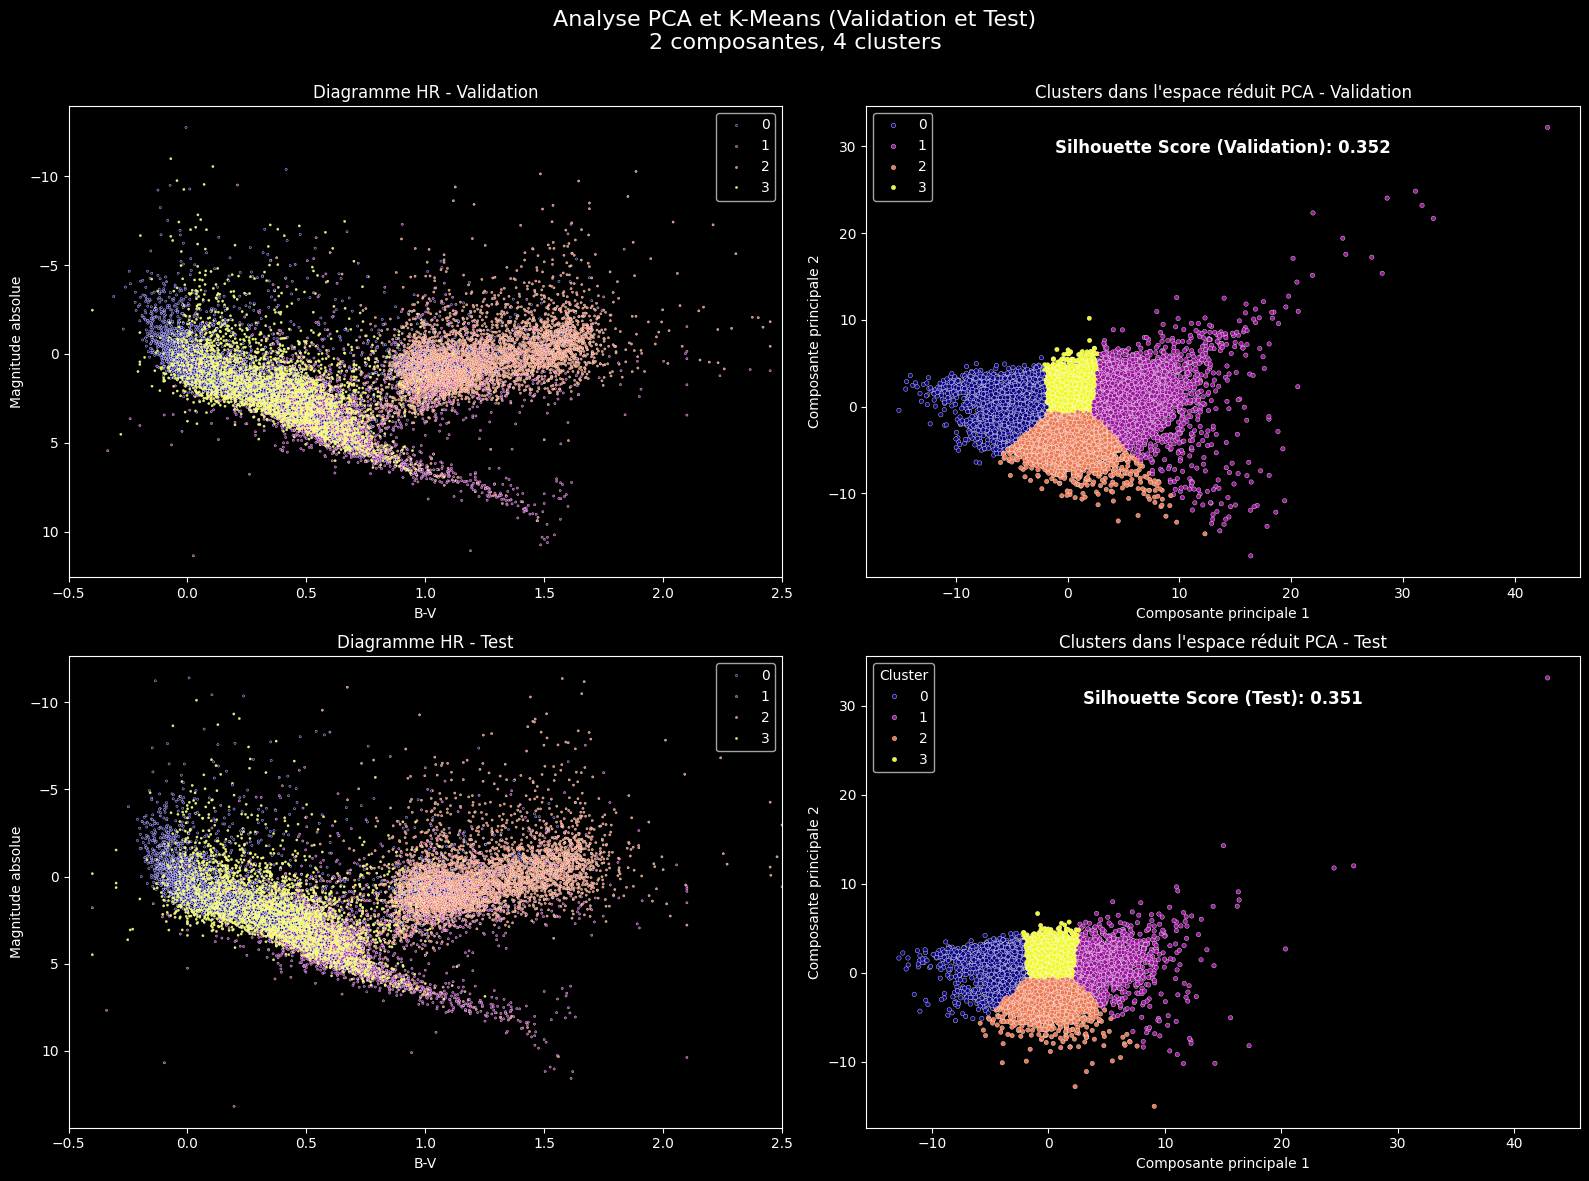

In [ ]:
# 2 composantes et 4 clusters
pca_kmeans(2, 4)

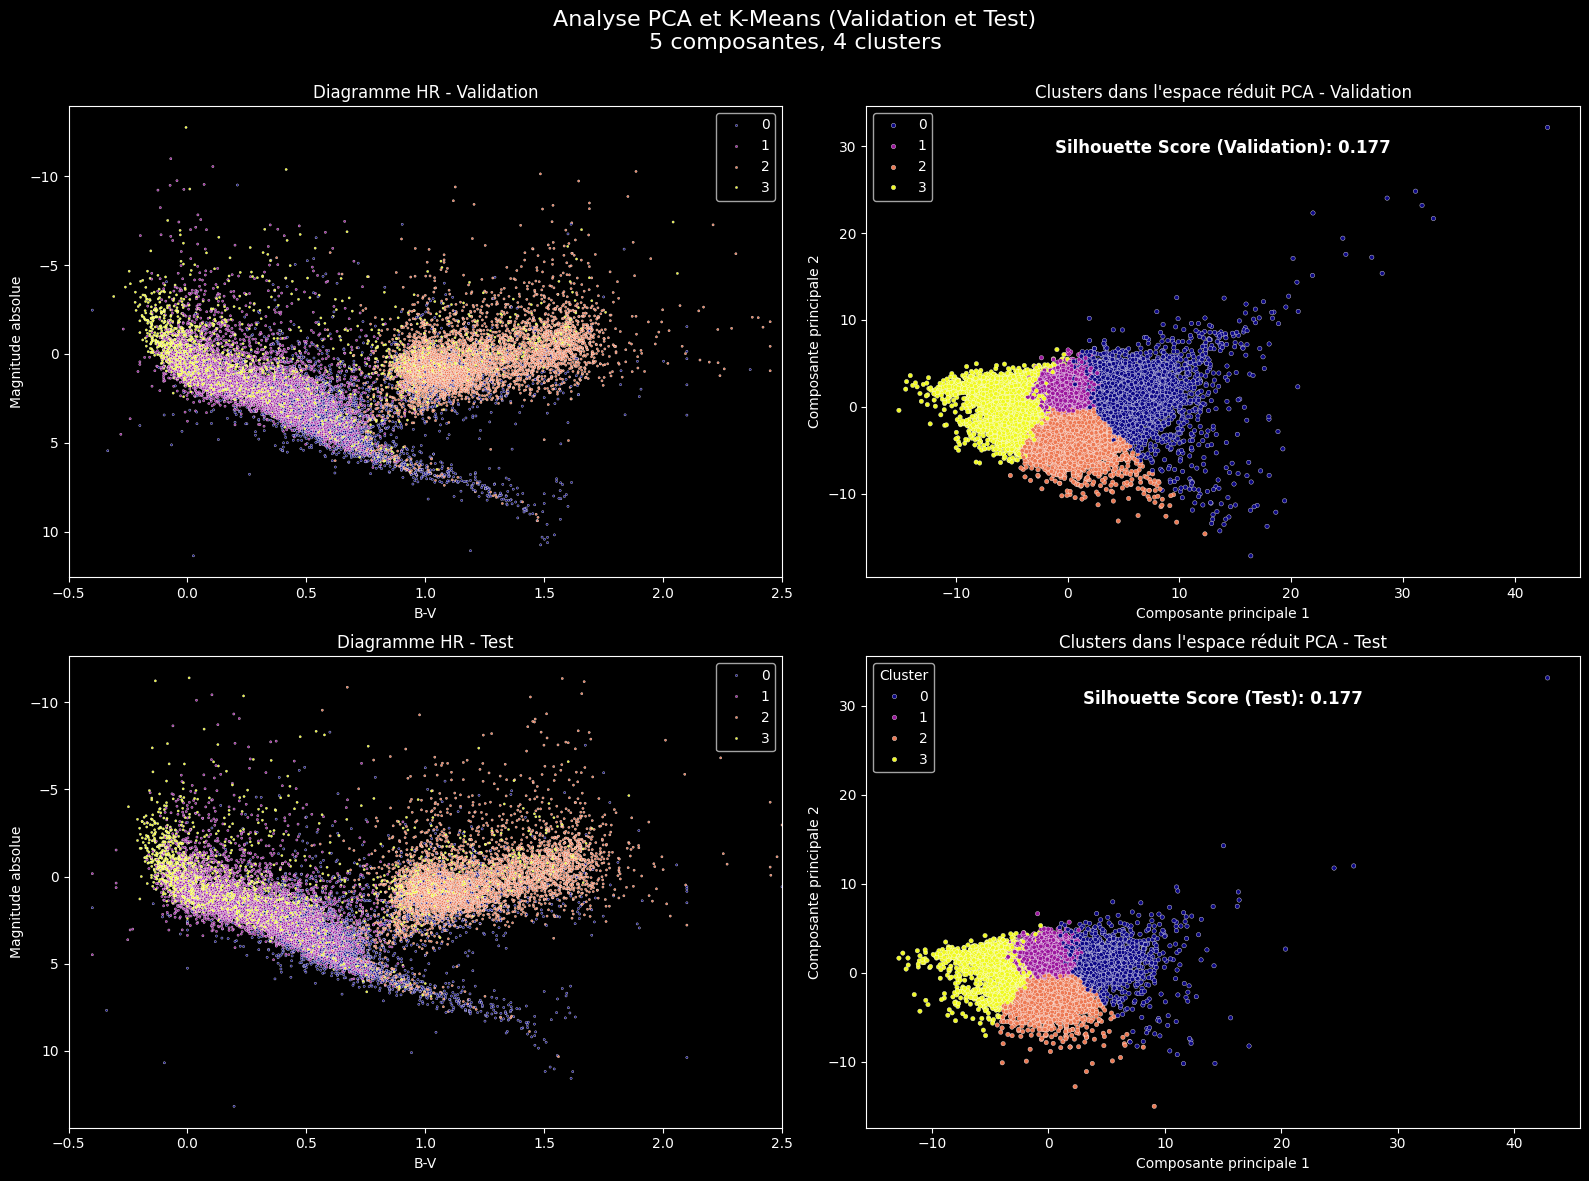

In [ ]:
# 5 composantes et 4 clusters
pca_kmeans(5, 4)

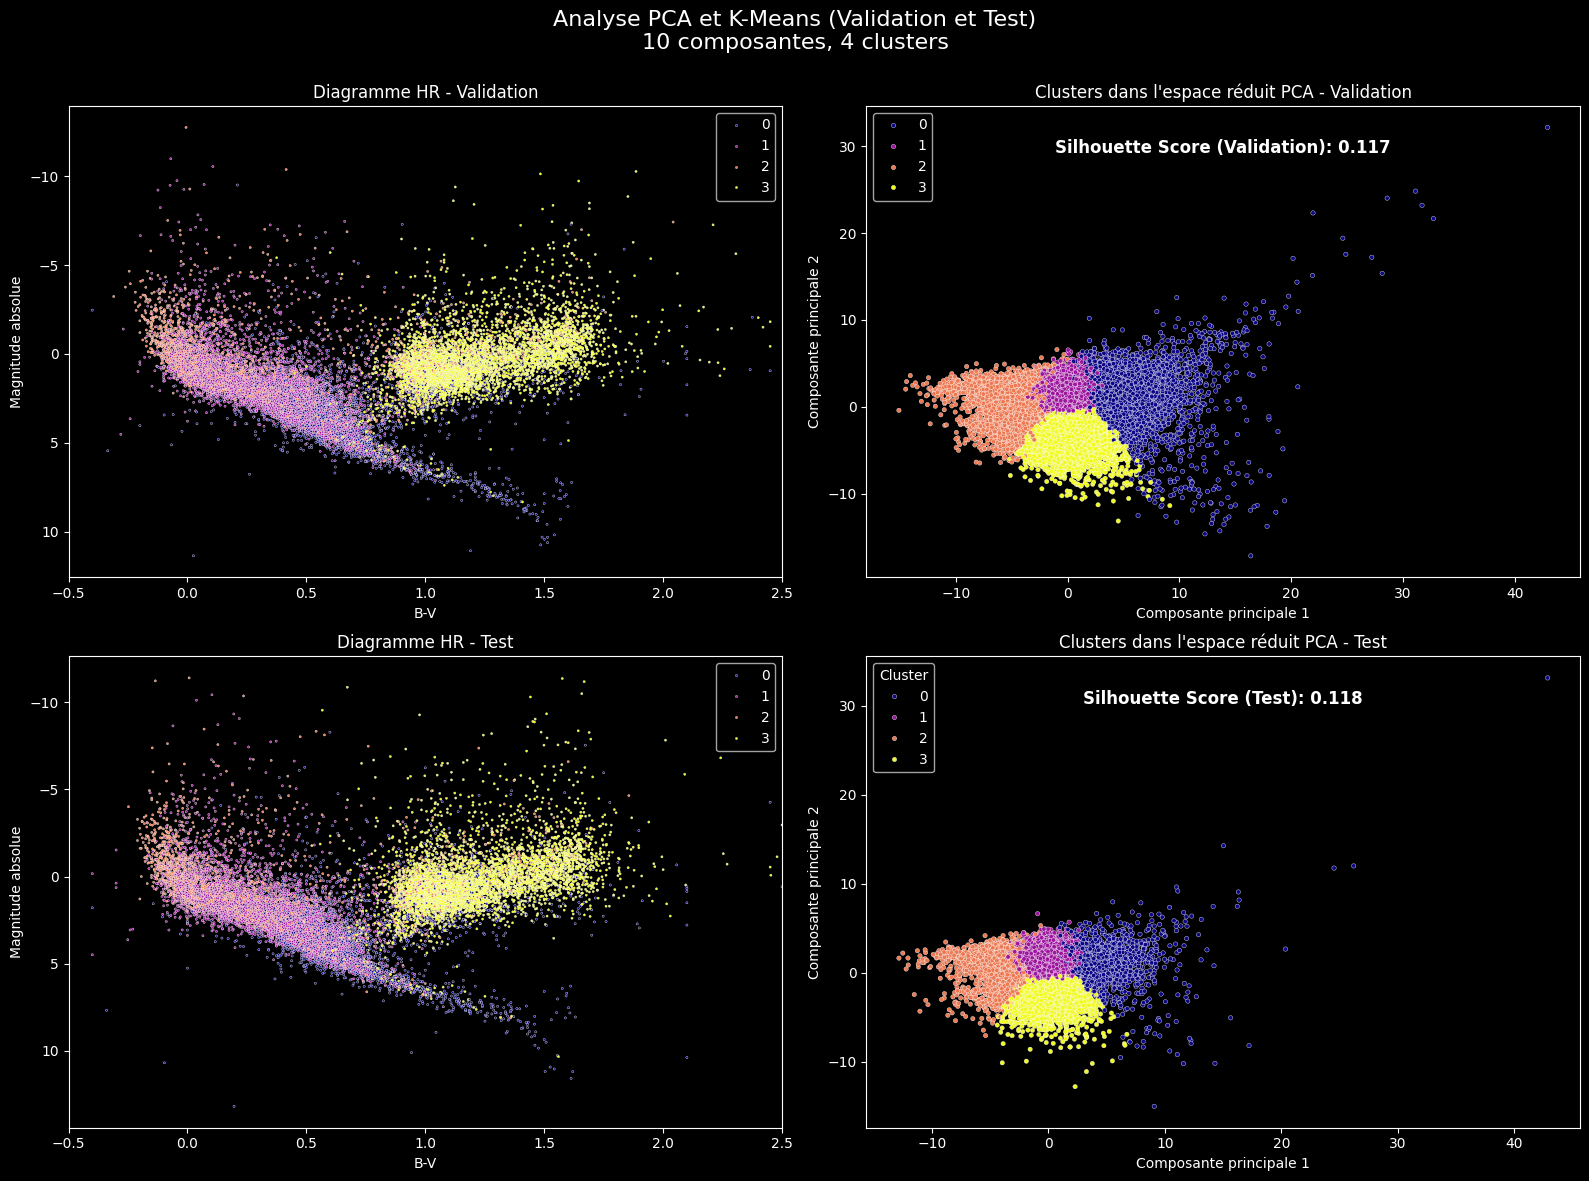

In [ ]:
# 10 composantes et 4 clusters
pca_kmeans(10, 4)

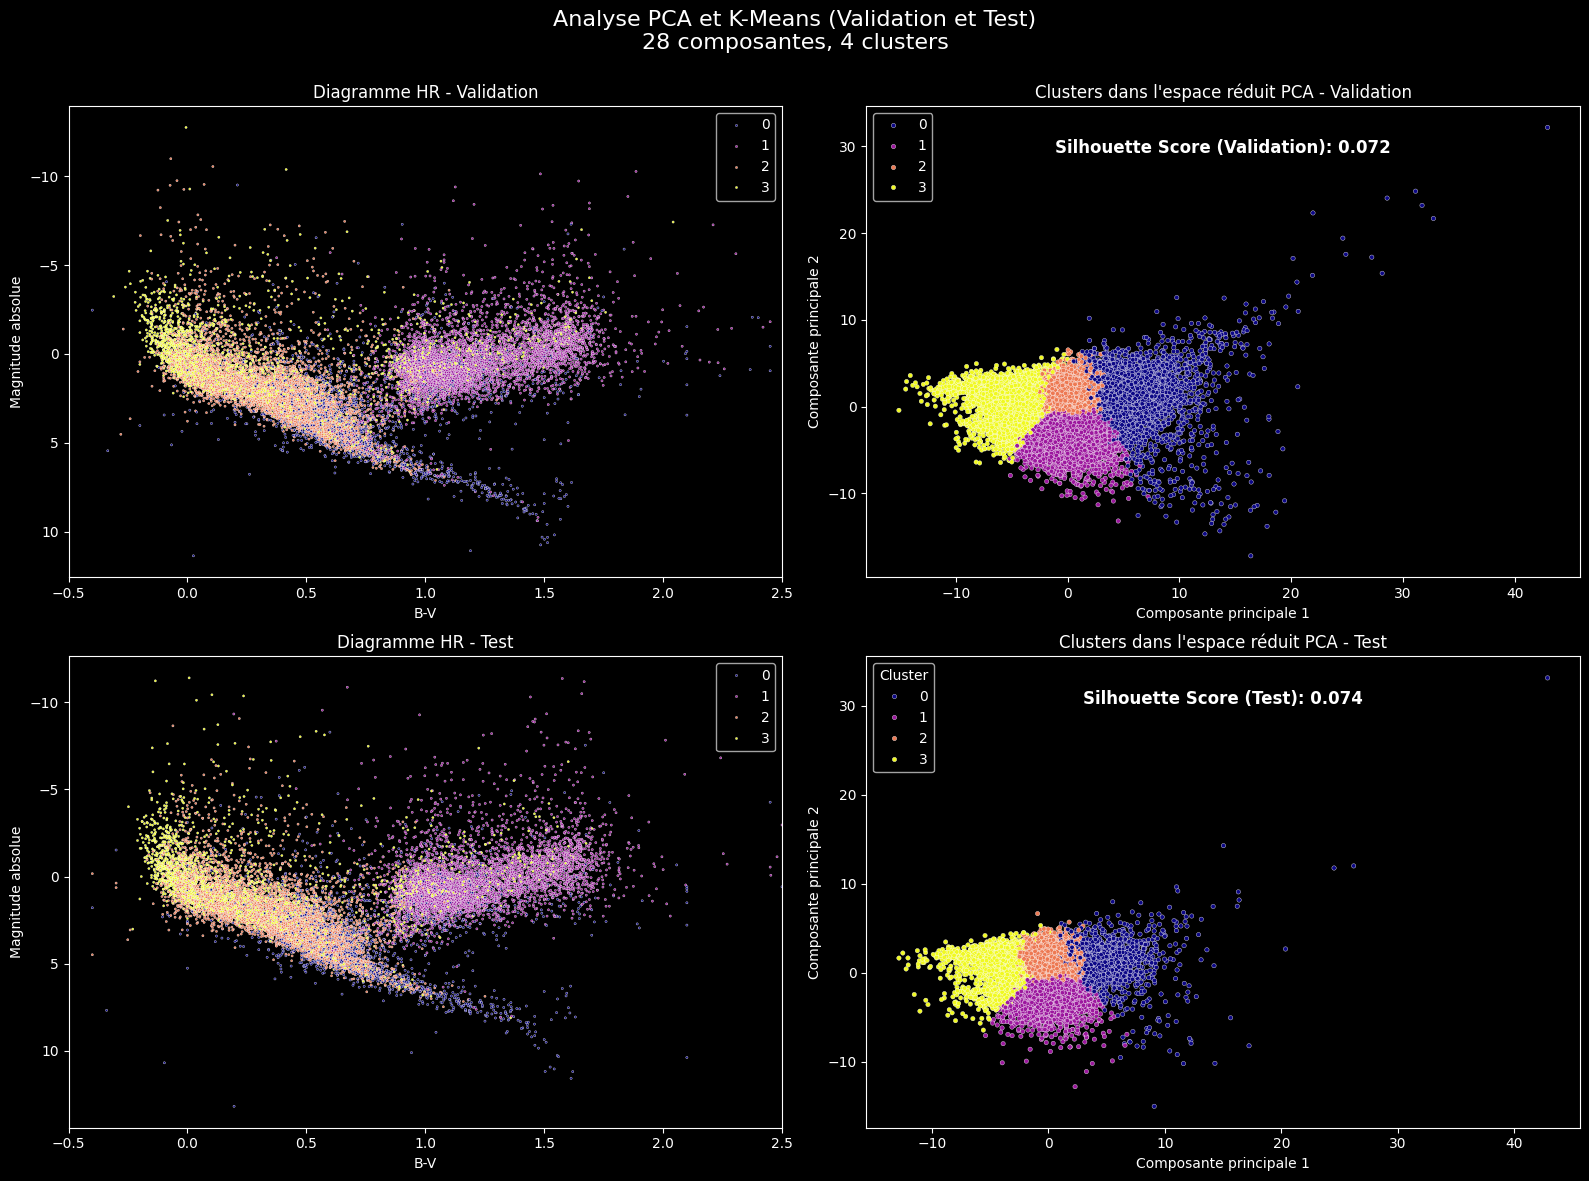

In [ ]:
# 28 composantes et 4 clusters
pca_kmeans(28, 4)

In [ ]:
"""
Données réelles --> [normalisation] --> données normalisées --> [PCA] --> données réduites --> [clustering]
        |                                                                                     |
        |                                                                                     V
        ------------------> Récupère les labels de cluster <---------------------- Ajouter dans données réelles
"""



"""trouver meilleure visualisation, faire les autres méthodes et essayer de trouver label pour comparer"""

'trouver meilleure visualisation, faire les autres méthodes et essayer de trouver label pour comparer'

## 5) DBSCAN (sans PCA)

In [ ]:
X_dbscan = X_train[['B-V', 'AbsoluteMag']].copy()

In [ ]:
dbscan = DBSCAN(eps=0.3, min_samples=6) # eps : distance maximale entre deux échantillons pour qu'un échantillon soit considéré comme étant dans le voisinage de l'autre

In [ ]:
# Prédire les clusters pour l'ensemble d'entraînement
train_clusters_dbscan = dbscan.fit_predict(X_dbscan) 

#  Ajouter les clusters comme une nouvelle colonne dans X_train
X_dbscan['Cluster'] = train_clusters_dbscan

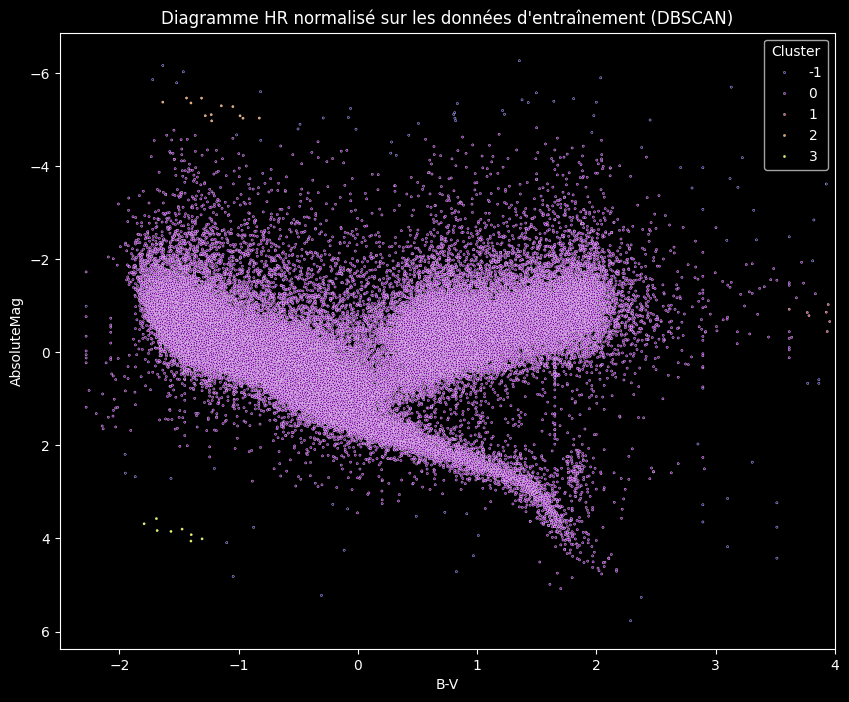

In [ ]:
plt.figure(figsize=(10, 8))
plt.style.use('dark_background')
sns.scatterplot(x=X_dbscan['B-V'], y=X_dbscan['AbsoluteMag'], hue=X_dbscan['Cluster'], palette='plasma', marker='.', s=10)   
plt.title("Diagramme HR normalisé sur les données d'entraînement (DBSCAN)")
plt.xlim(-2.5, 4)
plt.gca().invert_yaxis()  
plt.show()

In [ ]:
labels_cluster = dbscan.labels_

X_valid = X_dbscan[labels_cluster != -1]
labels_valid = labels_cluster[labels_cluster != -1]

In [ ]:
score = silhouette_score(X_valid, labels_valid) #pour faire l'évaluation il faut éliminer les points du cluster -1 (ce cluster correspond au bruit)
print("Silhouette Score :", score)

Silhouette Score : 0.5646094041023062


## 6) DBSCAN (avec PCA)

In [ ]:
# Entrainement du modèle
dbscan = DBSCAN(eps=0.3, min_samples=6)

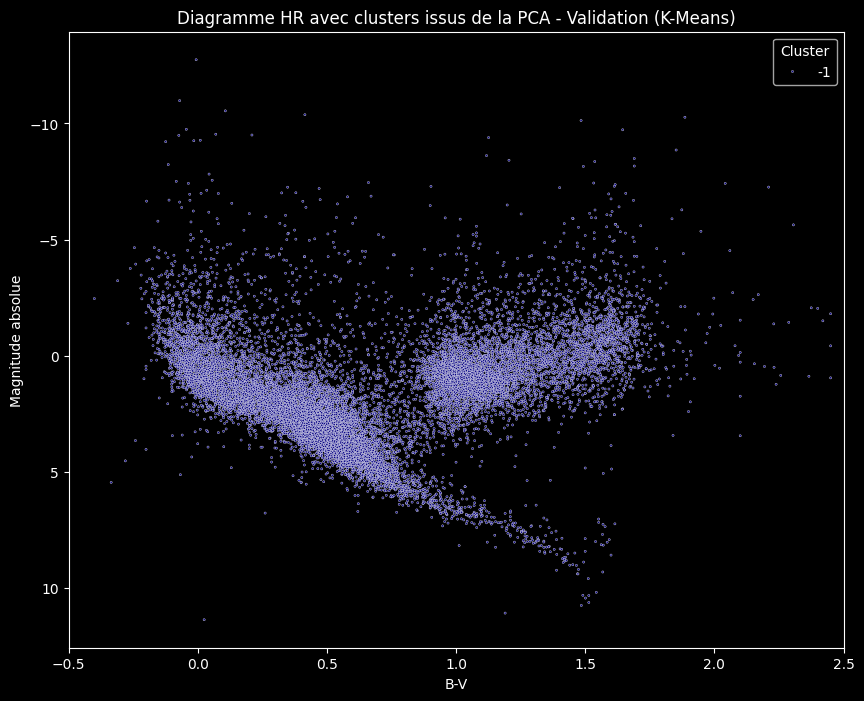

In [ ]:
# Prédire les clusters pour l'ensemble d'entraînement
train_clusters_dbscan_pca = dbscan.fit_predict(X_val_pca)

# Faire une copie des données utilisées pour la PCA 
X_val_hr_dbscan = X_val_pca.copy()
X_val_hr_dbscan = X_val_hr_dbscan.reset_index(drop=True)

# Ajouter les labels des clusters
X_val_hr_dbscan['Cluster'] = train_clusters_dbscan_pca

# Diagramme HR 
plt.figure(figsize=(10, 8))
plt.style.use('dark_background')
sns.scatterplot(x=X_val_hr_dbscan['B-V'], y=X_val_hr_dbscan['AbsoluteMag'], hue=X_val_hr_dbscan['Cluster'], palette='plasma', marker='.', s=10)   
plt.title("Diagramme HR avec clusters issus de la PCA - Validation (K-Means)")
plt.xlim(-0.5, 2.5)
plt.xlabel('B-V')
plt.ylabel('Magnitude absolue')
plt.gca().invert_yaxis() 
plt.show()



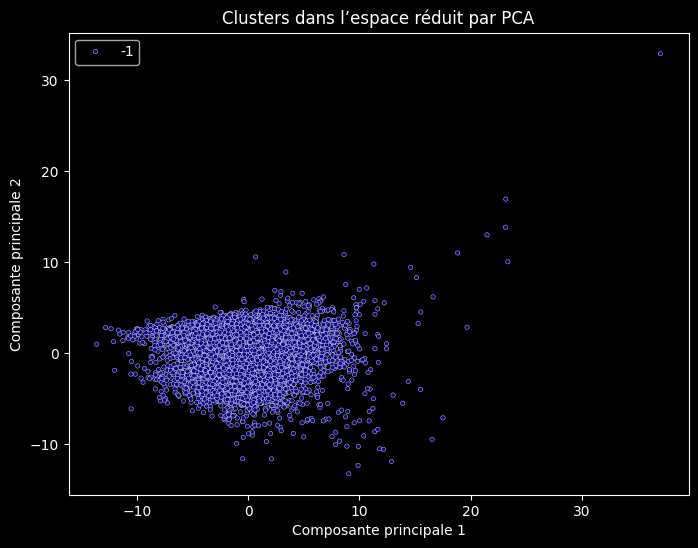

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_val_t_df['Col1'], y=X_val_t_df['Col2'], hue=dbscan.labels_, palette='plasma', s=10)
plt.title("Clusters dans l’espace réduit par PCA")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend()
plt.show()

## 7) GMM (sans PCA)

Taille du train : (78976, 8)
Taille du validation : (16923, 8)
Taille du test : (16924, 8)


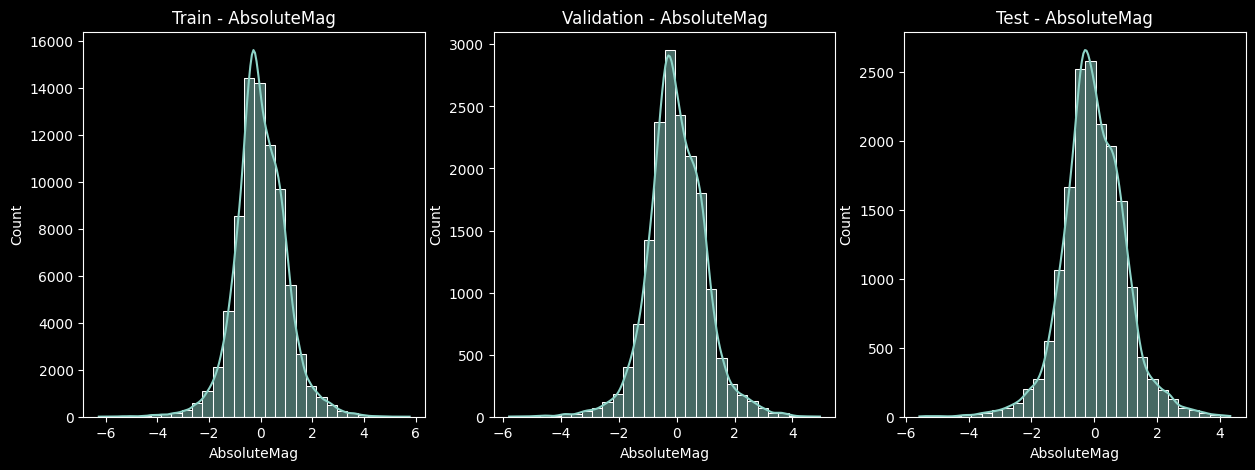

In [ ]:
# Séparation en train/validation/test
X_train, X_temp = train_test_split(X_scaled_df, test_size=0.3, random_state=0)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=0)

print(f"Taille du train : {X_train.shape}")
print(f"Taille du validation : {X_val.shape}")
print(f"Taille du test : {X_test.shape}")
#print(X_train)

# Visualiser les données de chaque ensemble (par exemple avec AbsoluteMag)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(X_train['AbsoluteMag'], bins=30, kde=True, ax=axes[0]).set_title("Train - AbsoluteMag")
sns.histplot(X_val['AbsoluteMag'], bins=30, kde=True, ax=axes[1]).set_title("Validation - AbsoluteMag")
sns.histplot(X_test['AbsoluteMag'], bins=30, kde=True, ax=axes[2]).set_title("Test - AbsoluteMag")
plt.show()

In [ ]:
X_gmm = X_train[['B-V', 'AbsoluteMag']].copy()

In [ ]:
gmm = GaussianMixture(n_components=4, random_state=0)
train_clusters_gmm = gmm.fit_predict(X_gmm)

X_gmm['Cluster_GMM'] = train_clusters_gmm


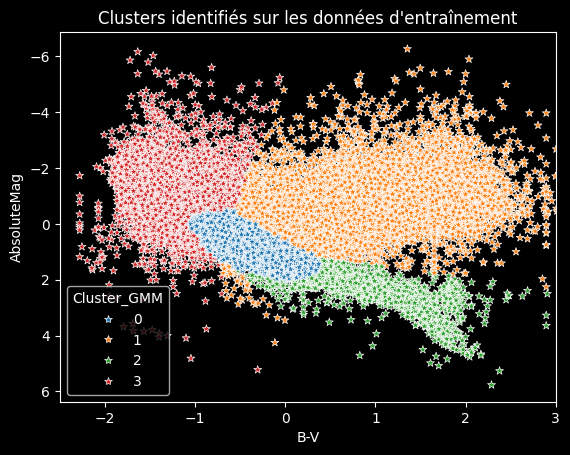

In [ ]:
sns.scatterplot(x=X_gmm['B-V'], y=X_gmm['AbsoluteMag'], hue=X_gmm['Cluster_GMM'], palette="tab10", marker="*")   
plt.title("Clusters identifiés sur les données d'entraînement")
plt.xlim(-2.5, 3)
plt.gca().invert_yaxis()  # il faut inverser l'axe de AbsoluteMag par convention du diagramme HR
plt.show()

## 7) GMM (sans PCA)

In [ ]:
# Séparation en train/validation/test
X_train, X_temp = train_test_split(data_t_df, test_size=0.3, random_state=0)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=0)

print(f"Taille du train : {X_train.shape}")
print(f"Taille du validation : {X_val.shape}")
print(f"Taille du test : {X_test.shape}")
#print(X_train)

Taille du train : (75443, 3)
Taille du validation : (16167, 3)
Taille du test : (16167, 3)


In [ ]:
gmm = GaussianMixture(n_components=4, random_state=0)
train_clusters_gmm = gmm.fit_predict(X_train)

X_train['Cluster_GMM'] = train_clusters_gmm


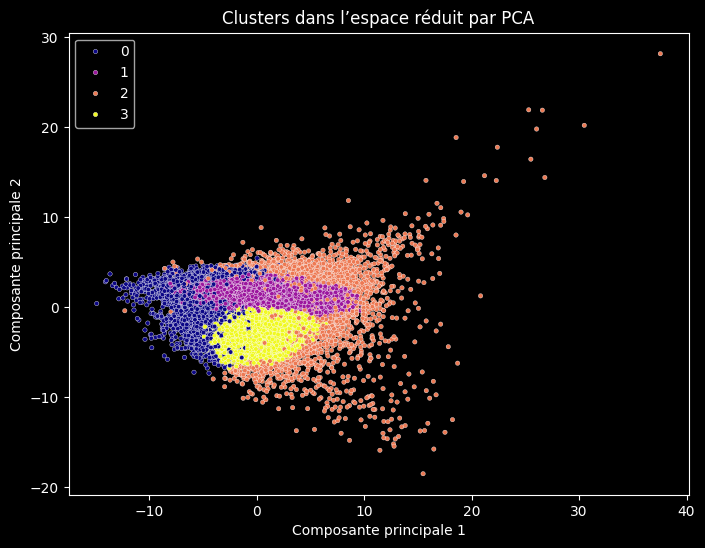

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_train['Col1'], y=X_train['Col2'], hue=train_clusters_gmm, palette='plasma', s=10)
plt.title("Clusters dans l’espace réduit par PCA")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend()
plt.show()

## 7) Bibliographie

https://www.cosmos.esa.int/documents/532822/552851/vol1_all.pdf/99adf6e3-6893-4824-8fc2-8d3c9cbba2b5

https://github.com/emjako/pythondatascientist/blob/master/notebooks/06_02_Machine_learning_non_supervise.ipynb

https://youtu.be/OGWwzm304Xs?si=QlNyxrJp5ZzzPE3h